In [1]:
!pip install -r  requirements.txt

# Lab 3: Simple Linear Regression

## Predicting Exam Score from Assignments

### Dataset

We use the **Student Clean Dataset**.

For this Simple Linear Regression lab, we use only:

- **Input feature (X): `Assignments`**
- **Target (y): `Exam_Score`**

The question we investigate is:

> **Can we predict a student's Exam Score using their Assignments?**

### Objectives

- Understand Simple Linear Regression.
- Implement the OLS solution manually using the provided functions.
- Calculate slope and intercept.
- Generate predictions.
- Calculate residuals.
- Evaluate the model using MAE, MSE, RMSE, and R².
- Implement the same model using Scikit-Learn.
- Compare the manual implementation with the predefined package implementation.


# File Structure

### `slr_ols_todo.py`

This file contains the **logic and function implementations**:

- `find_mean()`
- `find_slope_intercept()`
- `predict_lr()`
- `mae()`
- `mse()`
- `r_square()`
- `load_slr_dataset()`

### This Notebook

This notebook contains:

- Instructions
- Explanations
- Student Tasks
- Driving code
- Plots
- Scikit-Learn implementation
- Manual vs package comparison

The functions are **not redefined in the notebook**.


# 1. Import Libraries

### Student TODO

Import the required libraries and the provided `slr_ols_todo` module.

**Do not implement any logic in this cell.**


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
%load_ext autoreload
%autoreload 2

import slr_ols_todo as slr

# 2. Load the Dataset

The `load_slr_dataset()` function is already provided because downloading files is not part of the student implementation.

### Student TODO

Use `slr.load_slr_dataset()` to load the clean dataset and display it.

**Do not implement or modify the download logic.**


In [4]:
# Provided: dataset loading is not a student implementation task.
df = slr.load_slr_dataset(True)
display(df)


student_clean_dataset.csv already exists. Skipping download.
student_raw_dataset.csv already exists. Skipping download.


/Users/gourabrajak/Documents/Virtual Env/my_project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
0,ST001,18,Male,Computer Science,3,98,12,60,Pass,B,Not Placed,0.00
1,ST002,20,Male,Computer Science,1,81,11,44,Pass,D,Not Placed,0.00
2,ST003,19,Male,Computer Science,3,76,9,46,Pass,D,Not Placed,0.00
3,ST004,19,Female,Computer Science,5,100,10,51,Pass,C,Placed,3.39
4,ST005,18,Female,Computer Science,5,68,13,54,Pass,C,Placed,3.12
...,...,...,...,...,...,...,...,...,...,...,...,...
295,ST296,18,Male,Computer Science,8,86,16,74,Pass,A,Not Placed,0.00
296,ST297,19,Female,Computer Science,9,80,19,92,Pass,A+,Placed,19.43
297,ST298,18,Male,Mechanical,9,81,20,94,Pass,A+,Placed,14.97
298,ST299,19,Male,Computer Science,6,82,18,82,Pass,A+,Placed,7.40


# 3. Select X and y

For this lab:

- `Assignments` is the independent/input variable.
- `Exam_Score` is the dependent/target variable.

### Student TODO

Create `x` and `y` from the required columns.

Then inspect the input and target sizes.

**Focus:** Understand how the observations are split into input `X` and target `y`, and verify that they contain the same number of observations.


In [5]:
# TODO: Select the input feature and target.
x = df["Assignments"]
y = df["Exam_Score"]

# Provided: validation helps you inspect input/target sizes and data quality.
slr.validate_xy(x, y)

print("Input feature: Assignments")
print("Target variable: Exam_Score")
print("Number of observations:", len(df))


X shape: (300,)
y shape: (300,)

X data type:
int64

y data type:
int64

Missing values:
X: 0
y: 0

Number of observations:
X: 300
y: 300

X and y validation successful.
Input feature: Assignments
Target variable: Exam_Score
Number of observations: 300


# 4. Visualize the Relationship

The plotting code is provided for reference.

### Student TODO

No implementation is required in this section.

Use the provided visualization to understand the relationship between `Assignments` and `Exam_Score`.


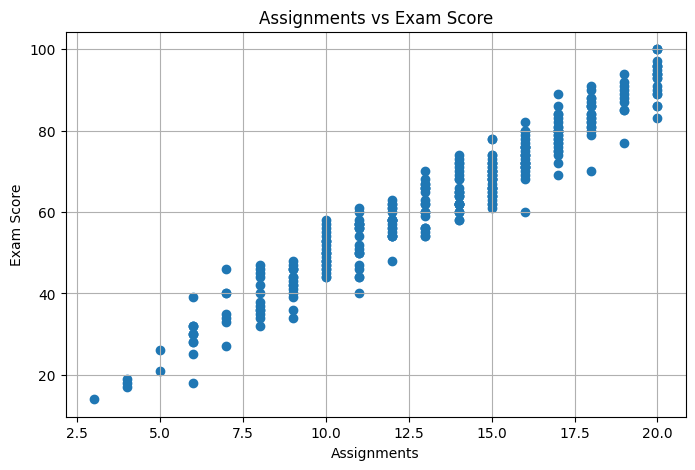

In [6]:
# Provided visualization — no student implementation required.
plt.figure(figsize=(8, 5))
plt.scatter(x, y)
plt.title("Assignments vs Exam Score")
plt.xlabel("Assignments")
plt.ylabel("Exam Score")
plt.grid(True)
plt.show()


# 5. Calculate the Mean

For Simple Linear Regression:

$[
\bar{x} = \frac{1}{n}\sum x_i
]$

$[
\bar{y} = \frac{1}{n}\sum y_i
]$

### Student TODO

Implement `find_mean()` in `slr_ols_todo.py`.

Then use it to calculate:

- mean of Assignments
- mean of Exam Score

**Core logic to implement:** sum the values and divide by the number of observations.


In [7]:
# TODO: Use your implementation of find_mean().
x_mean = slr.find_mean(x)
y_mean = slr.find_mean(y)

print("Mean Assignments:", x_mean)
print("Mean Exam Score:", y_mean)


Mean Assignments: 13.46
Mean Exam Score: 63.20666666666666


# 6. Calculate Slope and Intercept

The Simple Linear Regression equation is:

$[
\hat{y} = mx+b
]$

The OLS slope is:

$[
m =
\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}
{\sum (x_i-\bar{x})^2}
]$

The intercept is:

$[
b=\bar{y}-m\bar{x}
]$

### Student TODO

Implement `find_slope_intercept()` in `slr_ols_todo.py`.

Then use the function to calculate:

- slope `m`
- intercept `b`
- regression equation

**Core logic to implement:** calculate the numerator and denominator of the OLS slope, then calculate the intercept.


In [8]:
# TODO: Use your implementation of find_slope_intercept().
m, b = slr.find_slope_intercept(x, y, x_mean, y_mean)

print("Slope:", m)
print("Intercept:", b)
print(f"Regression equation: Exam_Score = {m:.4f} * Assignments + {b:.4f}")


Slope: 4.425869255751711
Intercept: 3.6344664842486267
Regression equation: Exam_Score = 4.4259 * Assignments + 3.6345


# 7. Generate Predictions

The prediction equation is:

$[
\hat{y}=mx+b
]$

### Student TODO

Implement `predict_lr()` in `slr_ols_todo.py`.

Then use it to generate the predicted Exam Score for every observation.

Create the Actual vs Predicted DataFrame using the provided notebook code structure.

**Core logic to implement:** apply the learned slope and intercept to each input value.


In [9]:
# TODO: Use your implementation of predict_lr().
y_pred = slr.predict_lr(x, m, b)

manual_results = pd.DataFrame({
    "Actual Exam Score": y,
    "Predicted Exam Score": y_pred
})

display(manual_results)


,Actual Exam Score,Predicted Exam Score
0,60,56.744898
1,44,52.319028
2,46,43.467290
3,51,47.893159
4,54,61.170767
...,...,...
295,74,74.448375
296,92,87.725982
297,94,92.151852
298,82,83.300113


# 8. Plot the Regression Line

The plotting code is provided.

### Student TODO

No plotting implementation is required.

Use the provided output only to understand the fitted regression line.


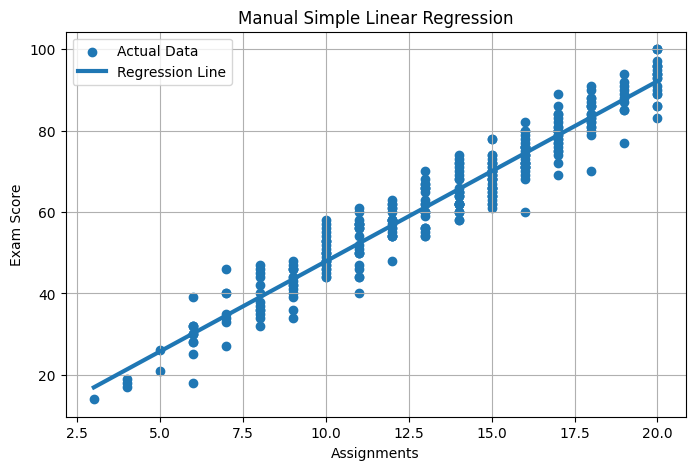

In [10]:
# Provided visualization — no student implementation required.
plot_order = np.argsort(x)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Actual Data")
plt.plot(
    x.iloc[plot_order],
    y_pred.iloc[plot_order],
    linewidth=3,
    label="Regression Line"
)
plt.title("Manual Simple Linear Regression")
plt.xlabel("Assignments")
plt.ylabel("Exam Score")
plt.legend()
plt.grid(True)
plt.show()


# 9. Residuals

A residual is:

$[
e_i=y_i-\hat{y}_i
]$

### Student TODO

Calculate the residuals from actual and predicted values.

Then use the provided plot to inspect them.

**Core logic to understand:** residual = actual value − predicted value.

No plotting implementation is required.


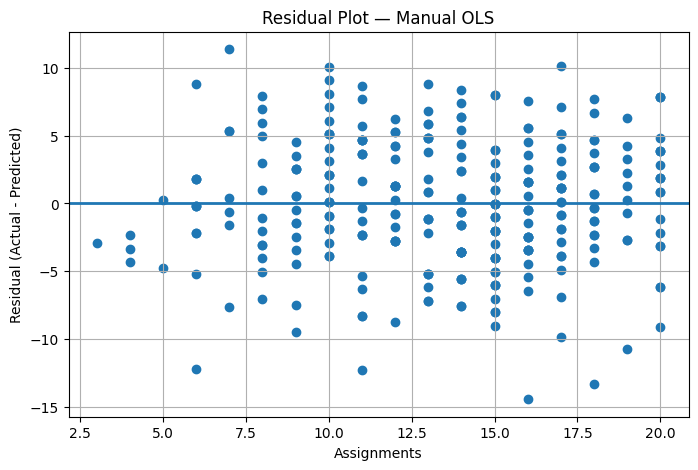

In [11]:
# TODO: Calculate residuals.
residuals = slr.calculate_residuals(y, y_pred)

plt.figure(figsize=(8, 5))
plt.scatter(x, residuals)
plt.axhline(0, linewidth=2)
plt.title("Residual Plot — Manual OLS")
plt.xlabel("Assignments")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True)
plt.show()


# 10. Mean Squared Error (MSE)

$[
MSE=\frac{1}{n}\sum(y_i-\hat{y}_i)^2
]$

### Student TODO

Implement `mse()` in `slr_ols_todo.py`.

Then use it to calculate MSE.

**Core logic to implement:** calculate the prediction errors, square them, and take their mean.


In [12]:
# TODO: Use your implementation of mse().
mse_value = slr.mse(y, y_pred)

print("MSE:", mse_value)


MSE: 21.395365153241517


# 11. Mean Absolute Error (MAE)

$[
MAE=\frac{1}{n}\sum|y_i-\hat{y}_i|
]$

### Student TODO

Implement `mae()` in `slr_ols_todo.py`.

Then use it to calculate MAE.

**Core logic to implement:** calculate the absolute prediction errors and take their mean.


In [13]:
# TODO: Use your implementation of mae().
mae_value = slr.mae(y, y_pred)

print("MAE:", mae_value)


MAE: 3.72194292192681


# 12. Root Mean Squared Error (RMSE)

$[
RMSE=\sqrt{MSE}
]$

### Student TODO

Calculate RMSE from the MSE produced by your implementation.

**Core logic:** RMSE is the square root of MSE.


In [14]:
# TODO: Calculate RMSE from your MSE.
rmse_value = slr.rmse(y, y_pred)

print("RMSE:", rmse_value)


RMSE: 4.625512420612609


# 13. R² Score

$[
R^2=1-\frac{SS_{residual}}{SS_{total}}
]$

where:

$[
SS_{total}=\sum(y_i-\bar{y})^2
]$

### Student TODO

Implement `r_square()` in `slr_ols_todo.py`.

Then use it to calculate R².

**Core logic to implement:** calculate total sum of squares, residual sum of squares, and apply the R² formula.


In [15]:
# TODO: Use your implementation of r_square().
r2_value = slr.r_square(y, y_pred, y_mean)

print("R²:", r2_value)


R²: 0.9347285623725479


# 14. Actual vs Predicted

The plotting code is provided.

### Student TODO

No plotting implementation is required.

Use the provided visualization to interpret actual versus predicted values.


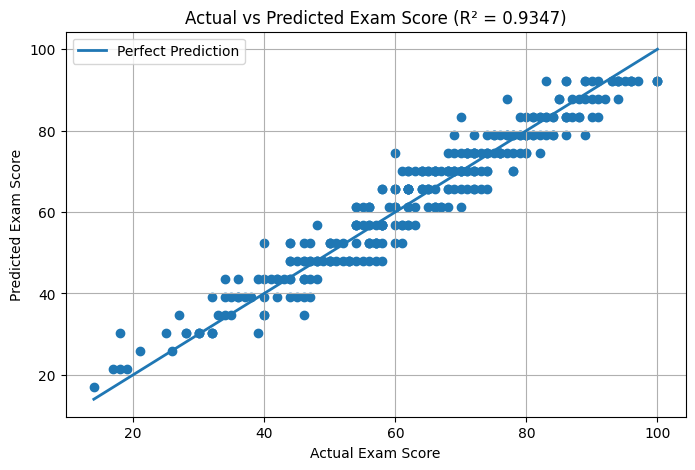

In [16]:
# Provided visualization — no student implementation required.
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred)

min_value = min(y.min(), y_pred.min())
max_value = max(y.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linewidth=2,
    label="Perfect Prediction"
)
plt.title(f"Actual vs Predicted Exam Score (R² = {r2_value:.4f})")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.legend()
plt.grid(True)
plt.show()


# 15. Manual Model Summary

### Student TODO

Use the values returned by your implemented functions to produce the manual model summary.

No comparison with Scikit-Learn is required in this section.


In [17]:
# Provided summary structure.
manual_summary = pd.DataFrame({
    "Measure": [
        "Slope",
        "Intercept",
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],
    "Manual OLS": [
        m,
        b,
        mae_value,
        mse_value,
        rmse_value,
        r2_value
    ]
})
display(manual_summary)


,Measure,Manual OLS
0,Slope,4.425869
1,Intercept,3.634466
2,MAE,3.721943
3,MSE,21.395365
4,RMSE,4.625512
5,R²,0.934729


# 16. Simple Linear Regression Using Scikit-Learn

Use the same `Assignments` and `Exam_Score` data.

### Student TODO

Prepare the input `X` and target `Y` in the format required by Scikit-Learn.

**Focus:** Understand the number of observations and the shape of the input matrix before training.


In [18]:
# TODO: Prepare X and Y in the format required by Scikit-Learn.
X = df[["Assignments"]]
Y = df["Exam_Score"]

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (300, 1)
Y shape: (300,)


# 17. Train the Scikit-Learn Model

### Student TODO

Create a `LinearRegression` object and train it using `X` and `Y`.

**Core logic:** understand the model-training step and how the input matrix and target vector are passed to `fit()`.


In [19]:
# TODO: Create and train the Scikit-Learn LinearRegression model.
regressor = LinearRegression()
regressor.fit(X, y)


LinearRegression()

# 18. Scikit-Learn Slope and Intercept

### Student TODO

Read and print the slope and intercept learned by the trained Scikit-Learn model.

No manual comparison is required here.


In [20]:
# TODO: Read the learned slope and intercept.
package_m = regressor.coef_[0]
package_b = regressor.intercept_

print("Slope:", package_m)
print("Intercept:", package_b)
print(
    f"Regression equation: Exam_Score = "
    f"{package_m:.4f} * Assignments + {package_b:.4f}"
)


Slope: 4.4258692557517145
Intercept: 3.634466484248584
Regression equation: Exam_Score = 4.4259 * Assignments + 3.6345


# 19. Scikit-Learn Predictions

### Student TODO

Use the trained Scikit-Learn model to generate predictions.

No manual comparison is required here.


In [21]:
# TODO: Generate predictions using the trained Scikit-Learn model.
y_package_pred = regressor.predict(X)

package_results = pd.DataFrame({
    "Actual Exam Score": Y,
    "Predicted Exam Score": y_package_pred
})
display(package_results)


,Actual Exam Score,Predicted Exam Score
0,60,56.744898
1,44,52.319028
2,46,43.467290
3,51,47.893159
4,54,61.170767
...,...,...
295,74,74.448375
296,92,87.725982
297,94,92.151852
298,82,83.300113


# 20. Scikit-Learn Residuals and Metrics

### Student TODO

Calculate:

- residuals
- MAE
- MSE
- RMSE
- R²

using the Scikit-Learn functions provided in the notebook.

The plotting portion is provided and is not a student implementation task.


MAE : 3.721942921926808
MSE : 21.395365153241517
RMSE: 4.625512420612609
R²  : 0.9347285623725479


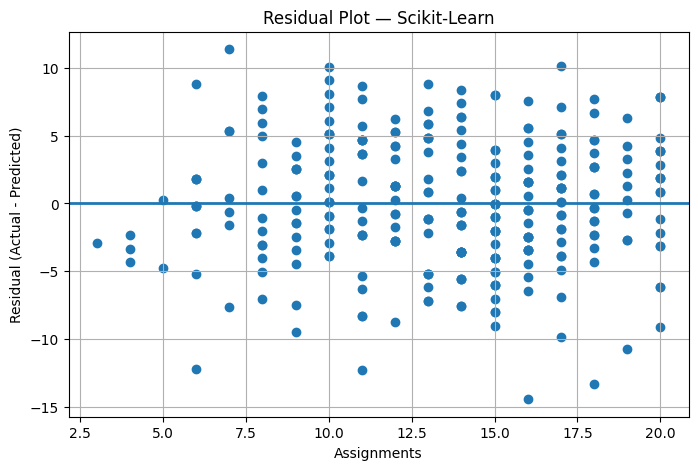

In [22]:
# TODO: Calculate Scikit-Learn residuals and metrics.
package_residuals = Y - y_package_pred
package_mae = mean_absolute_error(Y , y_package_pred)
package_mse = mean_squared_error(Y , y_package_pred)
package_rmse = np.sqrt(mean_squared_error(Y , y_package_pred))
package_r2 = r2_score(Y , y_package_pred)

print("MAE :", package_mae)
print("MSE :", package_mse)
print("RMSE:", package_rmse)
print("R²  :", package_r2)

# Provided visualization — no student implementation required.
plt.figure(figsize=(8, 5))
plt.scatter(X, package_residuals)
plt.axhline(0, linewidth=2)
plt.title("Residual Plot — Scikit-Learn")
plt.xlabel("Assignments")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True)
plt.show()


# 21. Manual vs Scikit-Learn Comparison

Both approaches use the same data and solve the same Simple Linear Regression problem.

### Student TODO

No manual comparison is required.

The comparison is provided so you can verify whether your implementation produces the expected results.


In [23]:
# Provided comparison — no manual comparison implementation required.
comparison = pd.DataFrame({
    "Measure": [
        "Slope",
        "Intercept",
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],
    "Manual OLS": [
        m,
        b,
        mae_value,
        mse_value,
        rmse_value,
        r2_value
    ],
    "Scikit-Learn": [
        package_m,
        package_b,
        package_mae,
        package_mse,
        package_rmse,
        package_r2
    ]
})
display(comparison)


,Measure,Manual OLS,Scikit-Learn
0,Slope,4.425869,4.425869
1,Intercept,3.634466,3.634466
2,MAE,3.721943,3.721943
3,MSE,21.395365,21.395365
4,RMSE,4.625512,4.625512
5,R²,0.934729,0.934729


# 22. Compare Predictions

### Student TODO

No manual comparison is required.

The provided cell displays the predictions from both approaches for verification.


In [24]:
# Provided prediction comparison — no manual comparison implementation required.
prediction_comparison = pd.DataFrame({
    "Actual Exam Score": Y,
    "Manual Prediction": y_pred.to_numpy(),
    "Scikit-Learn Prediction": y_package_pred
})
display(prediction_comparison)


,Actual Exam Score,Manual Prediction,Scikit-Learn Prediction
0,60,56.744898,56.744898
1,44,52.319028,52.319028
2,46,43.467290,43.467290
3,51,47.893159,47.893159
4,54,61.170767,61.170767
...,...,...,...
295,74,74.448375,74.448375
296,92,87.725982,87.725982
297,94,92.151852,92.151852
298,82,83.300113,83.300113


# 23. Final Verification

### Student TODO

Run the provided verification.

Use the results to confirm that your implemented functions and the Scikit-Learn model produce matching results up to normal floating-point precision.

Do not add a separate comparison implementation.


In [25]:
# Provided final verification — no student implementation required.
print("Slope matches:", np.isclose(m, package_m))
print("Intercept matches:", np.isclose(b, package_b))
print("Predictions match:", np.allclose(y_pred.to_numpy(), y_package_pred))
print("MAE matches:", np.isclose(mae_value, package_mae))
print("MSE matches:", np.isclose(mse_value, package_mse))
print("RMSE matches:", np.isclose(rmse_value, package_rmse))
print("R² matches:", np.isclose(r2_value, package_r2))


Slope matches: True
Intercept matches: True
Predictions match: True
MAE matches: True
MSE matches: True
RMSE matches: True
R² matches: True


# Final Questions

Answer briefly:

1. What does the slope represent in this model?
2. What does the intercept represent?
3. What is a residual?
4. What does a positive residual mean?
5. What does a negative residual mean?
6. What does MAE measure?
7. What does MSE measure?
8. Why is RMSE the square root of MSE?
9. What does R² tell us?
10. Why should manual OLS and Scikit-Learn produce almost identical results?
11. What is the advantage of implementing the method manually before using a package?

---

## Student Submission

Submit:

1. The completed `slr_ols_todo.py` file.
2. The completed Lab 3 notebook.
3. Answers to the final questions.

**Student implementation focus:** core regression logic, prediction logic, error calculations, input/target sizes and shapes, and Scikit-Learn model training. Plotting, file downloading, and manual comparison are provided and are not independent implementation tasks.
